In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/movielens-1m-dataset/users.dat
/kaggle/input/movielens-1m-dataset/ratings.dat
/kaggle/input/movielens-1m-dataset/README
/kaggle/input/movielens-1m-dataset/movies.dat


In [2]:
def get_file_path():
    paths = []
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            paths.append(os.path.join(dirname, filename))
    return paths    

In [3]:
paths = get_file_path()

print(paths)

['/kaggle/input/movielens-1m-dataset/users.dat', '/kaggle/input/movielens-1m-dataset/ratings.dat', '/kaggle/input/movielens-1m-dataset/README', '/kaggle/input/movielens-1m-dataset/movies.dat']


In [4]:
rating = pd.read_csv("/kaggle/input/movielens-1m-dataset/ratings.dat",header=None, sep='::', names=['uid','iid','rating','timestamp'],engine='python')
item_info = pd.read_csv("/kaggle/input/movielens-1m-dataset/movies.dat",sep='::',encoding='latin-1',engine='python',names=['iid','title','genres'])
user_info = pd.read_csv("/kaggle/input/movielens-1m-dataset/users.dat",sep='::',encoding='latin-1',engine='python',names=['uid','gender','age','occupation','zipcode'])

In [5]:
item_info.head()

,iid,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
user_info.head(2)

,uid,gender,age,occupation,zipcode
0,1,F,1,10,48067
1,2,M,56,16,70072


In [8]:
rating_ = pd.merge(rating,item_info,on='iid',how='inner')

In [9]:
rating_.head(2)

,uid,iid,rating,timestamp,title,genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical


In [10]:
date_min = pd.to_datetime(rating_.timestamp,unit='s').min() 
date_max = pd.to_datetime(rating_.timestamp,unit='s').max()

In [11]:
rating_['time'] = pd.to_datetime(rating_.timestamp,unit='s').map(lambda x: (x.year-date_min.year)*12+x.month)

In [12]:
rating_['time'] = rating_['time'] - rating_['time'].min()

In [13]:
np.sort(rating_.time.unique())

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34])

In [14]:
rating_.head(2)

,uid,iid,rating,timestamp,title,genres,time
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,8
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,8


<Axes: xlabel='time'>

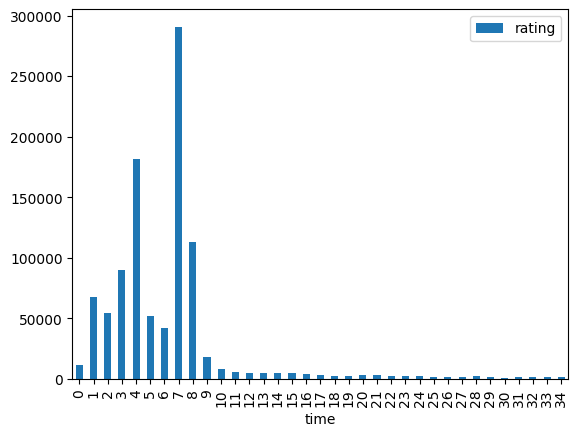

In [15]:
rating_.groupby('time').agg({'rating':'count'}).reset_index().plot(x='time',kind='bar')

In [16]:
rating_['label'] = rating_['rating'].apply(lambda x: 1 if x>=4 else 0)

In [17]:
rating_.head(5)

,uid,iid,rating,timestamp,title,genres,time,label
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,8,1
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,8,0
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,8,0
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,8,1
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,9,1


In [18]:
rating_.label.describe()

count    1.000209e+06
mean     5.751608e-01
std      4.943188e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: label, dtype: float64

In [19]:
rating_.uid.min(),rating_.uid.max(),rating_.iid.min(),rating_.iid.max()

(1, 6040, 1, 3952)

In [20]:
train_slot = list(range(14,24))
valid_slot = list(range(24,29))
test_slot = list(range(29,34))

In [21]:
rating_train = rating_[rating_['time'].isin(train_slot)].copy()
rating_valid = rating_[rating_['time'].isin(valid_slot)].copy()
rating_test = rating_[rating_['time'].isin(test_slot)].copy()

In [22]:
rating_train.shape, rating_valid.shape, rating_test.shape

((33891, 8), (10401, 8), (7331, 8))

In [23]:
rating_valid_f = rating_valid
rating_test_f = rating_test

In [24]:
rating_train['flag'] =  pd.DataFrame(np.ones(rating_train.shape[0])*-1, index=rating_train.index)
rating_valid_f['flag'] = pd.DataFrame(np.zeros(rating_valid_f.shape[0]), index=rating_valid_f.index)
rating_test_f['flag'] = pd.DataFrame(np.ones(rating_test_f.shape[0]), index=rating_test_f.index)
data = pd.concat([rating_train, rating_valid_f, rating_test_f],axis=0,ignore_index=True)
data = data.sort_values(by=['uid','timestamp'])
u_inter_all = data.groupby('uid').agg({'iid':list, 'label':list, 'title':list, 'timestamp':list,'flag':list})


In [25]:
data.flag.unique()

array([-1.,  1.,  0.])

In [27]:
import copy
def deal_with_each_u(x,u):
    items = np.array(x.iid)
    labels = np.array(x.label)
    titles = np.array(x.title)
    timestamp = np.array(x.timestamp)
    flags =  np.array(x.flag) 
    his = [0] # adding a '0' by default
    his_title = ['']
    results = []
    for i in range(items.shape[0]):
        results.append((u, items[i], timestamp[i], np.array(his), copy.copy(his_title),titles[i], labels[i], flags[i]))
        # training data
        if labels[i] > 0: # positive 
            his.append(items[i])
            his_title.append(titles[i])
    return results

In [28]:
results = []
for u in u_inter_all.index:
    results.extend(deal_with_each_u(u_inter_all.loc[u],u))

In [29]:
u_, i_, time_, label_, his_, his_title, title_,flag_ = [],[],[],[],[],[],[],[]
for re_ in results:
    u_.append(re_[0])
    i_.append(re_[1])
    time_.append(re_[2])
    his_.append(re_[3])
    his_title.append(re_[4])
    title_.append(re_[5])
    label_.append(re_[6])
    flag_.append(re_[7])

In [30]:
data = pd.DataFrame({"uid":u_,'iid':i_,'label':label_, 'timestamp': time_ , 'his':his_,'his_title':his_title,'title':title_, 'flag': flag_})

In [31]:
data.head(2)

,uid,iid,label,timestamp,his,his_title,title,flag
0,19,318,1,994556598,[0],[],"Shawshank Redemption, The (1994)",-1.0
1,19,1234,1,994556636,"[0, 318]","[, Shawshank Redemption, The (1994)]","Sting, The (1973)",-1.0


In [32]:
def remap_user_item_ids(data):
    """
    Remaps user and item IDs to a continuous index and updates historical interactions accordingly.

    Args:
        data (pd.DataFrame): Input DataFrame with 'uid', 'iid', and 'his' columns.

    Returns:
        pd.DataFrame: DataFrame with remapped user and item IDs.
    """
    # Generate unique user and item mappings
    users_map = {uid: idx + 1 for idx, uid in enumerate(data["uid"].unique())}
    items_map = {iid: idx + 1 for idx, iid in enumerate(data["iid"].unique())}

    # Ensure 0 maps to 0
    users_map[0] = 0
    items_map[0] = 0

    # Apply mappings to DataFrame
    data["uid"] = data["uid"].map(users_map)
    data["iid"] = data["iid"].map(items_map)

    # Update historical interactions using efficient `.apply()`
    data["his"] = data["his"].apply(lambda hist: [items_map.get(k, 0) for k in hist])

    return data

In [33]:
data = remap_user_item_ids(data)

In [34]:
data.tail(5)

,uid,iid,label,timestamp,his,his_title,title,flag
51618,838,1619,1,997454429,"[0, 574, 742, 1633, 15, 1894, 1052, 848, 237, ...","[, Dreamlife of Angels, The (La Vie rêvée des ...",Body Heat (1981),-1.0
51619,838,728,1,997454464,"[0, 574, 742, 1633, 15, 1894, 1052, 848, 237, ...","[, Dreamlife of Angels, The (La Vie rêvée des ...",Pi (1998),-1.0
51620,838,407,0,997454464,"[0, 574, 742, 1633, 15, 1894, 1052, 848, 237, ...","[, Dreamlife of Angels, The (La Vie rêvée des ...",As Good As It Gets (1997),-1.0
51621,838,1362,0,997454486,"[0, 574, 742, 1633, 15, 1894, 1052, 848, 237, ...","[, Dreamlife of Angels, The (La Vie rêvée des ...",Crimson Tide (1995),-1.0
51622,838,42,1,998315055,"[0, 574, 742, 1633, 15, 1894, 1052, 848, 237, ...","[, Dreamlife of Angels, The (La Vie rêvée des ...","Godfather: Part II, The (1974)",-1.0


In [35]:
data.label.describe()

count    51623.000000
mean         0.536273
std          0.498687
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: label, dtype: float64

In [36]:
train_ = data[data['flag'].isin([-1])].copy()
valid_ = data[data['flag'].isin([0])].copy()
test_ = data[data['flag'].isin([1])].copy()
train_.shape,valid_.shape,test_.shape

((33891, 8), (10401, 8), (7331, 8))

In [37]:
train_user = train_['uid'].unique()
train_item = train_['iid'].unique()
valid_['not_cold'] = valid_[['uid','iid']].apply(lambda x: x.uid in train_user and x.iid in train_item, axis=1).astype("int")
test_['not_cold'] = test_[['uid','iid']].apply(lambda x: x.uid in train_user and x.iid in train_item, axis=1).astype("int")
train_['not_cold'] = pd.DataFrame(np.ones(train_.shape[0]),index=train_.index).astype("int")
train_.head(2)

,uid,iid,label,timestamp,his,his_title,title,flag,not_cold
0,1,1,1,994556598,[0],[],"Shawshank Redemption, The (1994)",-1.0,1
1,1,2,1,994556636,"[0, 1]","[, Shawshank Redemption, The (1994)]","Sting, The (1973)",-1.0,1


In [38]:
# Define Kaggle output directory
save_path = "/kaggle/working/"

# Ensure directory exists
os.makedirs(save_path, exist_ok=True)

# Save DataFrames as pickle files
train_.to_pickle(os.path.join(save_path, "train_ood2.pkl"))
valid_.to_pickle(os.path.join(save_path, "valid_ood2.pkl"))
test_.to_pickle(os.path.join(save_path, "test_ood2.pkl"))

print(f"Files saved to {save_path}")

Files saved to /kaggle/working/


## Warm Cold Data

In [39]:
user_info = train_.groupby('uid').agg({"label":'count'})
user_info.shape
train_user = np.array(list(user_info.index))

In [40]:
user_info.quantile(0.2)

label    5.0
Name: 0.2, dtype: float64

In [41]:
user_info = user_info[user_info.label>3] 
user_info.shape

(635, 1)

In [42]:
item_info = train_.groupby('iid').agg({"label":'count'})
item_info.shape

train_item = np.array(list(item_info.index))

In [43]:
item_info.describe()

,label
count,3087.000000
mean,10.978620
std,12.641559
min,1.000000
25%,2.000000
50%,6.000000
75%,15.000000
max,154.000000


In [44]:
item_info.quantile(0.3),item_info.shape

(label    3.0
 Name: 0.3, dtype: float64,
 (3087, 1))

In [45]:
item_info = item_info[item_info.label>3] 
item_info.shape

(2058, 1)

In [46]:
warm_user = np.array(list(user_info.index))
warm_item = np.array(list(item_info.index))

In [47]:
warm_user.shape, warm_item.shape, train_user.shape, train_item.shape

((635,), (2058,), (740,), (3087,))

In [48]:
test_['warm'] = test_[['uid','iid']].apply(lambda x: x.uid in warm_user and x.iid in warm_item, axis=1).astype("int")
test_['cold'] = test_[['uid','iid']].apply(lambda x: x.uid not in train_user and x.iid not in train_item, axis=1).astype("int")

In [49]:
test_.shape

(7331, 11)

In [50]:
test_.head()

,uid,iid,label,timestamp,his,his_title,title,flag,not_cold,warm,cold
97,4,96,1,1040544350,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Indecent Proposal (1993),1.0,1,1,0
98,4,97,1,1040544350,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Deconstructing Harry (1997),1.0,1,1,0
99,4,98,0,1040544494,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Big Daddy (1999),1.0,1,1,0
100,4,99,1,1040544521,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",But I'm a Cheerleader (1999),1.0,1,1,0
101,4,100,1,1040544564,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Desperately Seeking Susan (1985),1.0,1,1,0


In [51]:
test_[['not_cold','warm','cold']].describe()

,not_cold,warm,cold
count,7331.000000,7331.000000,7331.000000
mean,0.566498,0.480426,0.003547
std,0.495592,0.499651,0.059452
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000


In [ ]:
# Define Kaggle output directory
save_path = "/kaggle/working/"

# Ensure directory exists
os.makedirs(save_path, exist_ok=True)

# Save DataFrames as pickle files
test_.to_pickle(os.path.join(save_path, "test_warm_cold_ood2.pkl"))


print(f"Files saved to {save_path}")